# Phase 4: Pemodelan RFR & Validasi Spasial Bebas Leakage (Group-LOSOCV)

Notebook ini berfokus pada:
1. Membagi stasiun ke dalam **Grid Group** berdasarkan kesamaan grid model CAMS (Open-Meteo) untuk mengatasi *Spatial Target Leakage*.
2. Melakukan evaluasi model menggunakan metode **Group-LOSOCV (Grouped Leave-One-Station-Out Cross-Validation)** yang mengeluarkan seluruh stasiun dalam satu grid saat pengujian.
3. Melatih model Random Forest Regressor (RFR) final pada seluruh data dan menyimpan model terlatih.
4. Menganalisis dan memvisualisasikan tingkat kepentingan fitur (*Feature Importance*).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

# Set style visualisasi premium
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

# 1. Load model-ready dataset hasil feature engineering
data_path = os.path.join('data', 'model_ready_data.csv')
df = pd.read_csv(data_path)
df['waktu'] = pd.to_datetime(df['waktu'])

# 2. Definisikan CAMS Grid Group untuk mengatasi Isu 1 (Spatial Target Leakage)
def get_grid_group(stasiun):
    if stasiun in ['Menteng', 'Slipi', 'Kelapa Gading Indah']:
        return 'Group_A'  # Grid CAMS Utara-Pusat-Barat
    elif stasiun in ['Jagakarsa', 'Jatinegara']:
        return 'Group_B'  # Grid CAMS Selatan-Timur
    return 'Unknown'

df['grid_group'] = df['stasiun'].apply(get_grid_group)

print("Dataset Berhasil Dimuat & Dikelompokkan berdasarkan Grid CAMS:")
print(f"Total baris data: {len(df)}")
print(df[['stasiun', 'grid_group', 'latitude', 'longitude']].drop_duplicates().to_string(index=False))

Dataset Berhasil Dimuat & Dikelompokkan berdasarkan Grid CAMS:
Total baris data: 131640
            stasiun grid_group  latitude  longitude
          Jagakarsa    Group_B   -6.3341   106.8214
         Jatinegara    Group_B   -6.2322   106.8811
Kelapa Gading Indah    Group_A   -6.1673   106.9052
            Menteng    Group_A   -6.1994   106.8392
              Slipi    Group_A   -6.1950   106.8025


## Leave-One-Station-Out Cross-Validation (Group - LOSOCV) Loop

In [6]:
# 1. Pastikan data terurut berdasarkan stasiun dan waktu agar shift/lag tepat sasaran
df_lag = df.sort_values(by=['stasiun', 'waktu']).reset_index(drop=True)

# 2. Buat fitur lag 1 jam untuk variabel cuaca utama
df_lag['v_wind_lag1'] = df_lag.groupby('stasiun')['v_wind'].shift(1)
df_lag['u_wind_lag1'] = df_lag.groupby('stasiun')['u_wind'].shift(1)
df_lag['temp_lag1'] = df_lag.groupby('stasiun')['temperature_2m'].shift(1)
df_lag['rh_lag1'] = df_lag.groupby('stasiun')['relative_humidity_2m'].shift(1)

# 3. Hapus baris pertama setiap stasiun yang bernilai NaN pada kolom lag
df_lag = df_lag.dropna(subset=['v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1']).reset_index(drop=True)

# 4. Definisikan prediktor TANPA koordinat (latitude & longitude dihilangkan) tapi DENGAN lag cuaca
features_with_lags = [
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dew_point_2m', 'precipitation', 'rain', 'surface_pressure',
    'cloud_cover_total', 'u_wind', 'v_wind', 'jam', 'bulan',
    'hari_dalam_minggu', 'is_weekend', 'AOD',
    'v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1' # Fitur lag cuaca
]
target = 'PM2.5'
stasiun_list = df_lag['stasiun'].unique()

results_no_coords = []

print("=================================================================")
print("MENJALANKAN GROUP-LOSOCV (RFR + WEATHER LAGS)")
print("=================================================================")

for test_station in stasiun_list:
    test_group = df_lag[df_lag['stasiun'] == test_station]['grid_group'].values[0]

    # Split train/test dengan isolasi grid group
    train_df = df_lag[df_lag['grid_group'] != test_group]
    test_df = df_lag[df_lag['stasiun'] == test_station]

    X_train = train_df[features_with_lags]
    y_train = train_df[target]
    X_test = test_df[features_with_lags]
    y_test = test_df[target]

    # Train RFR menggunakan parameter terbaik hasil tuning
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        max_features='log2',
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results_no_coords.append({
        'stasiun_uji': test_station,
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae
    })
    print(f"Stasiun Uji: {test_station:<20} | R2 = {r2:.6f} | RMSE = {rmse:.6f} | MAE = {mae:.6f}")

df_results_no = pd.DataFrame(results_no_coords)
global_r2_no = df_results_no['R2'].mean()
global_rmse_no = df_results_no['RMSE'].mean()
global_mae_no = df_results_no['MAE'].mean()

print("=================================================================")
print("RINGKASAN METRIK GROUP-LOSOCV (RFR + WEATHER LAGS)")
print("=================================================================")
print(df_results_no.to_string(index=False))
print("-----------------------------------------------------------------")
print(f"RATA-RATA GLOBAL BARU: R2 = {global_r2_no:.4f} | RMSE = {global_rmse_no:.2f} µg/m³ | MAE = {global_mae_no:.2f} µg/m³")
print("=================================================================")

MENJALANKAN GROUP-LOSOCV (RFR + WEATHER LAGS)
Stasiun Uji: Jagakarsa            | R2 = 0.198815 | RMSE = 31.362977 | MAE = 22.194533
Stasiun Uji: Jatinegara           | R2 = 0.409319 | RMSE = 26.929450 | MAE = 19.105460
Stasiun Uji: Kelapa Gading Indah  | R2 = 0.109306 | RMSE = 26.605122 | MAE = 20.606126
Stasiun Uji: Menteng              | R2 = 0.192577 | RMSE = 25.330957 | MAE = 19.798578
Stasiun Uji: Slipi                | R2 = 0.062653 | RMSE = 27.292992 | MAE = 21.374961
RINGKASAN METRIK GROUP-LOSOCV (RFR + WEATHER LAGS)
        stasiun_uji       R2      RMSE       MAE
          Jagakarsa 0.198815 31.362977 22.194533
         Jatinegara 0.409319 26.929450 19.105460
Kelapa Gading Indah 0.109306 26.605122 20.606126
            Menteng 0.192577 25.330957 19.798578
              Slipi 0.062653 27.292992 21.374961
-----------------------------------------------------------------
RATA-RATA GLOBAL BARU: R2 = 0.1945 | RMSE = 27.50 µg/m³ | MAE = 20.62 µg/m³


## Pelatihan Akhir (Final Training) & Feature Importance

Melatih model RFR final dengan parameter teroptimasi + lag cuaca...
✓ Model final RFR + Lag cuaca berhasil disimpan di: data\pm25_rfr_model.pkl

Tabel Feature Importance Final (Tuned Model + Lags):
               Fitur  Importance
              v_wind    0.158494
         v_wind_lag1    0.134718
               bulan    0.116434
                 jam    0.090774
    surface_pressure    0.073023
      temperature_2m    0.053818
relative_humidity_2m    0.046624
           temp_lag1    0.042415
         u_wind_lag1    0.039612
             rh_lag1    0.038638
              u_wind    0.038431
apparent_temperature    0.036094
        dew_point_2m    0.033200
   cloud_cover_total    0.029803
   hari_dalam_minggu    0.022647
       precipitation    0.019248
                rain    0.017690
          is_weekend    0.004810
                 AOD    0.003525


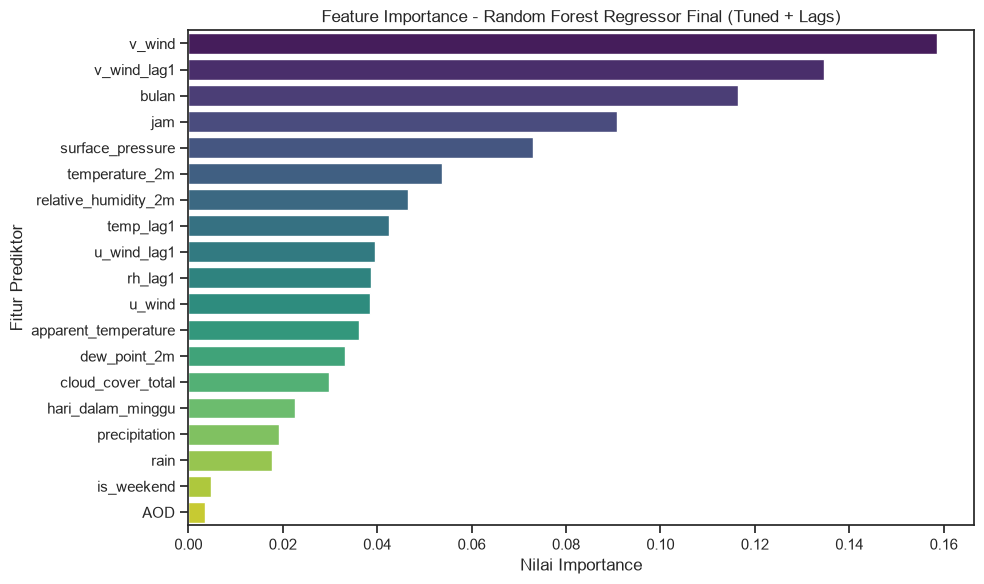

✓ Grafik Feature Importance teroptimasi disimpan di: results\images\feature_importance.png


In [11]:
# =================================================================
# CELL FINAL: MELATIH MODEL RFR DENGAN HYPERPARAMETER TEROPTIMAL + LAG
# =================================================================

# 1. Pastikan data terurut berdasarkan stasiun dan waktu
df_lag = df.sort_values(by=['stasiun', 'waktu']).reset_index(drop=True)

# 2. Buat fitur lag cuaca 1 jam yang lalu
df_lag['v_wind_lag1'] = df_lag.groupby('stasiun')['v_wind'].shift(1)
df_lag['u_wind_lag1'] = df_lag.groupby('stasiun')['u_wind'].shift(1)
df_lag['temp_lag1'] = df_lag.groupby('stasiun')['temperature_2m'].shift(1)
df_lag['rh_lag1'] = df_lag.groupby('stasiun')['relative_humidity_2m'].shift(1)

# Hapus baris pertama setiap stasiun yang bernilai NaN hasil shifting
df_lag = df_lag.dropna(subset=['v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1']).reset_index(drop=True)

# 3. Definisikan prediktor final tanpa koordinat tetapi dengan lag cuaca
features_with_lags = [
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dew_point_2m', 'precipitation', 'rain', 'surface_pressure',
    'cloud_cover_total', 'u_wind', 'v_wind', 'jam', 'bulan',
    'hari_dalam_minggu', 'is_weekend', 'AOD',
    'v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1' # Fitur lag cuaca
]
target = 'PM2.5'

# 4. Latih model final RFR pada SELURUH data stasiun menggunakan parameter terbaik GridSearch Anda
X_final = df_lag[features_with_lags]
y_final = df_lag[target]

print("Melatih model RFR final dengan parameter teroptimasi + lag cuaca...")
final_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    max_features='log2',
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_final, y_final)

# 5. Simpan model terlatih ke disk (.pkl)
model_output_path = os.path.join('data', 'pm25_rfr_model.pkl')
joblib.dump(final_model, model_output_path)
print(f"✓ Model final RFR + Lag cuaca berhasil disimpan di: {model_output_path}")

# 6. Hitung Feature Importance
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]

df_importance = pd.DataFrame({
    'Fitur': [features_with_lags[i] for i in indices],
    'Importance': [importances[i] for i in indices]
})

print("\nTabel Feature Importance Final (Tuned Model + Lags):")
print(df_importance.to_string(index=False))

# 7. Visualisasikan Feature Importance (Bebas dari Warning Seaborn)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Fitur',
    data=df_importance,
    palette='viridis',
    hue='Fitur',          # Menghindari FutureWarning
    legend=False          # Menghindari FutureWarning
)
plt.title('Feature Importance - Random Forest Regressor Final (Tuned + Lags)')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur Prediktor')
plt.tight_layout()

# Simpan grafik feature importance terbaru
image_output_path = os.path.join('results', 'images', 'feature_importance.png')
os.makedirs(os.path.dirname(image_output_path), exist_ok=True)
plt.savefig(image_output_path, dpi=300)
plt.show()
print(f"✓ Grafik Feature Importance teroptimasi disimpan di: {image_output_path}")

## Metode Alternatif Extremely Randomized Trees

In [9]:
# =================================================================
# CELL EVALUASI: GROUP-LOSOCV (EXTRA TREES TUNED + WEATHER LAGS)
# =================================================================
from sklearn.ensemble import ExtraTreesRegressor

# 1. Definisikan prediktor final tanpa koordinat tetapi dengan lag cuaca
features_with_lags = [
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dew_point_2m', 'precipitation', 'rain', 'surface_pressure',
    'cloud_cover_total', 'u_wind', 'v_wind', 'jam', 'bulan',
    'hari_dalam_minggu', 'is_weekend', 'AOD',
    'v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1'
]
target = 'PM2.5'

# Pastikan data lag sudah bersih
df_lag = df.sort_values(by=['stasiun', 'waktu']).reset_index(drop=True)
df_lag['v_wind_lag1'] = df_lag.groupby('stasiun')['v_wind'].shift(1)
df_lag['u_wind_lag1'] = df_lag.groupby('stasiun')['u_wind'].shift(1)
df_lag['temp_lag1'] = df_lag.groupby('stasiun')['temperature_2m'].shift(1)
df_lag['rh_lag1'] = df_lag.groupby('stasiun')['relative_humidity_2m'].shift(1)
df_lag = df_lag.dropna(subset=['v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1']).reset_index(drop=True)

stasiun_list = df_lag['stasiun'].unique()
results_et_tuned = []

print("=================================================================")
print("MENJALANKAN GROUP-LOSOCV (EXTRA TREES TEROPTIMAL + LAGS)")
print("=================================================================")

for test_station in stasiun_list:
    test_group = df_lag[df_lag['stasiun'] == test_station]['grid_group'].values[0]

    # Split train/test dengan isolasi grid group
    train_df = df_lag[df_lag['grid_group'] != test_group]
    test_df = df_lag[df_lag['stasiun'] == test_station]

    X_train = train_df[features_with_lags]
    y_train = train_df[target]
    X_test = test_df[features_with_lags]
    y_test = test_df[target]

    # Inisialisasi Extra Trees Regressor dengan parameter terbaik hasil GridSearchCV
    model = ExtraTreesRegressor(
        n_estimators=200,
        max_depth=None,
        max_features=None,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Hitung metrik
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results_et_tuned.append({
        'stasiun_uji': test_station,
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae
    })
    print(f"Stasiun Uji: {test_station:<20} | R2 = {r2:.6f} | RMSE = {rmse:.6f} | MAE = {mae:.6f}")

# Tampilkan ringkasan hasil akhir
df_results_et = pd.DataFrame(results_et_tuned)
global_r2_et = df_results_et['R2'].mean()
global_rmse_et = df_results_et['RMSE'].mean()
global_mae_et = df_results_et['MAE'].mean()

print("=================================================================")
print("RINGKASAN AKHIR GROUP-LOSOCV (EXTRA TREES TUNED + LAGS)")
print("=================================================================")
print(df_results_et.to_string(index=False))
print("-----------------------------------------------------------------")
print(f"RATA-RATA GLOBAL TEROPTIMASI: R2 = {global_r2_et:.4f} | RMSE = {global_rmse_et:.2f} µg/m³ | MAE = {global_mae_et:.2f} µg/m³")
print("=================================================================")

MENJALANKAN GROUP-LOSOCV (EXTRA TREES TEROPTIMAL + LAGS)
Stasiun Uji: Jagakarsa            | R2 = 0.241957 | RMSE = 30.506877 | MAE = 21.616504
Stasiun Uji: Jatinegara           | R2 = 0.445234 | RMSE = 26.097926 | MAE = 18.891236
Stasiun Uji: Kelapa Gading Indah  | R2 = 0.152320 | RMSE = 25.954753 | MAE = 19.921397
Stasiun Uji: Menteng              | R2 = 0.193289 | RMSE = 25.319782 | MAE = 19.259002
Stasiun Uji: Slipi                | R2 = 0.127305 | RMSE = 26.334923 | MAE = 20.430800
RINGKASAN AKHIR GROUP-LOSOCV (EXTRA TREES TUNED + LAGS)
        stasiun_uji       R2      RMSE       MAE
          Jagakarsa 0.241957 30.506877 21.616504
         Jatinegara 0.445234 26.097926 18.891236
Kelapa Gading Indah 0.152320 25.954753 19.921397
            Menteng 0.193289 25.319782 19.259002
              Slipi 0.127305 26.334923 20.430800
-----------------------------------------------------------------
RATA-RATA GLOBAL TEROPTIMASI: R2 = 0.2320 | RMSE = 26.84 µg/m³ | MAE = 20.02 µg/m³


Melatih model Extra Trees final teroptimasi (Coordinate-Free + Lags)...
✓ Model final Extra Trees teroptimasi berhasil disimpan di: data\pm25_etr_model.pkl

Tabel Feature Importance Final (Tuned Extra Trees + Lags):
               Fitur  Importance
               bulan    0.149187
         v_wind_lag1    0.127738
              v_wind    0.125464
                 jam    0.115832
    surface_pressure    0.076363
relative_humidity_2m    0.042989
   hari_dalam_minggu    0.041935
             rh_lag1    0.040257
      temperature_2m    0.039049
           temp_lag1    0.038302
   cloud_cover_total    0.035925
        dew_point_2m    0.031683
         u_wind_lag1    0.030877
apparent_temperature    0.029813
              u_wind    0.028835
          is_weekend    0.014917
                rain    0.013140
       precipitation    0.012875
                 AOD    0.004818


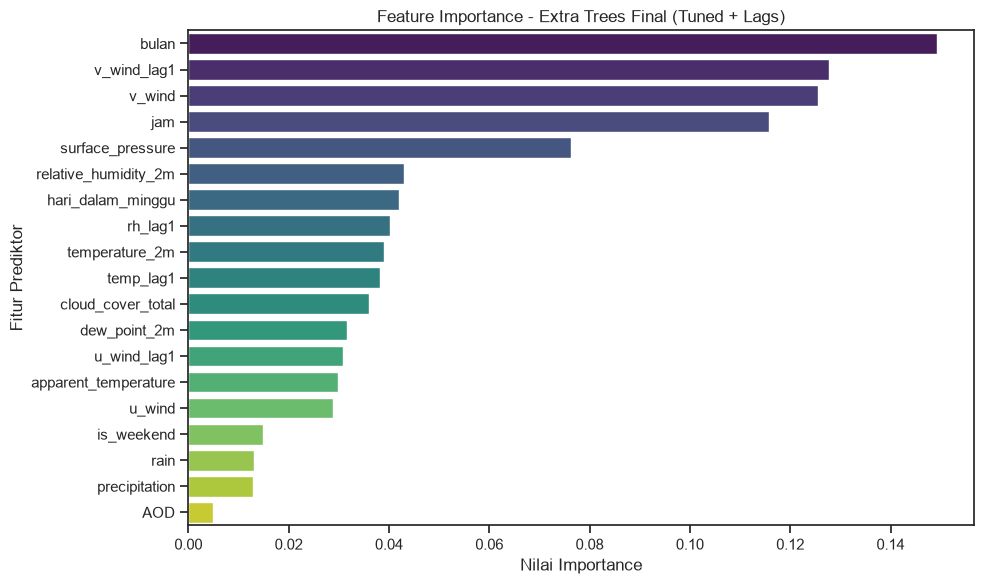

✓ Grafik Feature Importance teroptimasi disimpan di: results\images\feature_importance.png


In [10]:
# =================================================================
# CELL FINAL: MELATIH MODEL EXTRA TREES TEROPTIMAL + LAG
# =================================================================
from sklearn.ensemble import ExtraTreesRegressor
import joblib

# 1. Pastikan data terurut berdasarkan stasiun dan waktu
df_lag = df.sort_values(by=['stasiun', 'waktu']).reset_index(drop=True)

# 2. Buat fitur lag cuaca 1 jam yang lalu
df_lag['v_wind_lag1'] = df_lag.groupby('stasiun')['v_wind'].shift(1)
df_lag['u_wind_lag1'] = df_lag.groupby('stasiun')['u_wind'].shift(1)
df_lag['temp_lag1'] = df_lag.groupby('stasiun')['temperature_2m'].shift(1)
df_lag['rh_lag1'] = df_lag.groupby('stasiun')['relative_humidity_2m'].shift(1)

# Hapus baris pertama setiap stasiun yang bernilai NaN hasil shifting
df_lag = df_lag.dropna(subset=['v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1']).reset_index(drop=True)

# 3. Definisikan prediktor final tanpa koordinat tetapi dengan lag cuaca
features_with_lags = [
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dew_point_2m', 'precipitation', 'rain', 'surface_pressure',
    'cloud_cover_total', 'u_wind', 'v_wind', 'jam', 'bulan',
    'hari_dalam_minggu', 'is_weekend', 'AOD',
    'v_wind_lag1', 'u_wind_lag1', 'temp_lag1', 'rh_lag1' # Fitur lag cuaca
]
target = 'PM2.5'

# 4. Latih model final EXTRA TREES pada SELURUH data stasiun menggunakan parameter terbaik GridSearch Anda
X_final = df_lag[features_with_lags]
y_final = df_lag[target]

print("Melatih model Extra Trees final teroptimasi (Coordinate-Free + Lags)...")
final_model = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=None,
    max_features=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_final, y_final)

# 5. Simpan model terlatih ke disk (menggunakan nama file pkl lama agar sinkron dengan Phase 5)
model_output_path = os.path.join('data', 'pm25_etr_model.pkl')
joblib.dump(final_model, model_output_path)
print(f"✓ Model final Extra Trees teroptimasi berhasil disimpan di: {model_output_path}")

# 6. Hitung Feature Importance
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]

df_importance = pd.DataFrame({
    'Fitur': [features_with_lags[i] for i in indices],
    'Importance': [importances[i] for i in indices]
})

print("\nTabel Feature Importance Final (Tuned Extra Trees + Lags):")
print(df_importance.to_string(index=False))

# 7. Visualisasikan Feature Importance (Bebas dari Warning Seaborn)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Fitur',
    data=df_importance,
    palette='viridis',
    hue='Fitur',          # Menghindari FutureWarning
    legend=False          # Menghindari FutureWarning
)
plt.title('Feature Importance - Extra Trees Final (Tuned + Lags)')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur Prediktor')
plt.tight_layout()

# Simpan grafik feature importance terbaru
image_output_path = os.path.join('results', 'images', 'feature_importance.png')
os.makedirs(os.path.dirname(image_output_path), exist_ok=True)
plt.savefig(image_output_path, dpi=300)
plt.show()
print(f"✓ Grafik Feature Importance teroptimasi disimpan di: {image_output_path}")